In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

possible_paths = [
    Path("titanic.csv"),
    Path("analytics/titanic.csv")
]

DATA_PATH = next(
    (path for path in possible_paths if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find titanic.csv. Check that it exists inside analytics."
    )

df = pd.read_csv(DATA_PATH)

print("Loaded from:", DATA_PATH.resolve())
print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Loaded from: E:\zepto-ai-ml-capstone\analytics\titanic.csv
Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone

In [2]:
target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Feature shape: (891, 14)
Target shape: (891,)

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Target proportions:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [3]:
columns_to_drop = [
    "alive",
    "class",
    "who",
    "adult_male",
    "alone",
    "embark_town",
    "deck"
]

X = X.drop(columns=columns_to_drop, errors="ignore")

print("Remaining features:")
print(X.columns.tolist())

Remaining features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [4]:
missing_summary = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percentage": X.isna().mean() * 100
})

print(missing_summary)

          missing_count  missing_percentage
pclass                0            0.000000
sex                   0            0.000000
age                 177           19.865320
sibsp                 0            0.000000
parch                 0            0.000000
fare                  0            0.000000
embarked              2            0.224467


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))

X_train: (712, 7)
X_test: (179, 7)
y_train: (712,)
y_test: (179,)

Training target proportions:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing target proportions:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [6]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [8]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (712, 10)
Processed testing shape: (179, 10)


In [9]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 10

Processed feature names:
['numeric__pclass' 'numeric__age' 'numeric__sibsp' 'numeric__parch'
 'numeric__fare' 'categorical__sex_female' 'categorical__sex_male'
 'categorical__embarked_C' 'categorical__embarked_Q'
 'categorical__embarked_S']


In [10]:
processed_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

print(processed_train_df.head())
print("\nMissing values after preprocessing:")
print(processed_train_df.isna().sum().sum())

print("\nProcessed means:")
print(processed_train_df.mean().round(3))

     numeric__pclass  numeric__age  numeric__sibsp  numeric__parch  \
692         0.829568     -0.081135       -0.465084       -0.466183   
481        -0.370945     -0.081135       -0.465084       -0.466183   
527        -1.571457     -0.081135       -0.465084       -0.466183   
855         0.829568     -0.887827       -0.465084        0.727782   
801        -0.370945      0.110934        0.478335        0.727782   

     numeric__fare  categorical__sex_female  categorical__sex_male  \
692       0.513812                      0.0                    1.0   
481      -0.662563                      0.0                    1.0   
527       3.955399                      0.0                    1.0   
855      -0.467874                      1.0                    0.0   
801      -0.115977                      1.0                    0.0   

     categorical__embarked_C  categorical__embarked_Q  categorical__embarked_S  
692                      0.0                      0.0                      1.

In [11]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    preprocessor,
    MODEL_DIR / "titanic_preprocessor.joblib"
)

print("Preprocessor saved successfully.")
print("Saved to:", (MODEL_DIR / "titanic_preprocessor.joblib").resolve())

Preprocessor saved successfully.
Saved to: E:\zepto-ai-ml-capstone\analytics\models\titanic_preprocessor.joblib


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Logistic Regression
- Decision Tree
- Random Forest


In [14]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for model_name, model in models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    trained_models[model_name] = model_pipeline
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.8045     0.7931  0.6667    0.7244   0.8437
1        Decision Tree    0.7654     0.7547  0.5797    0.6557   0.7971
2        Random Forest    0.8156     0.8000  0.6957    0.7442   0.8300


In [15]:
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300
1,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
2,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971


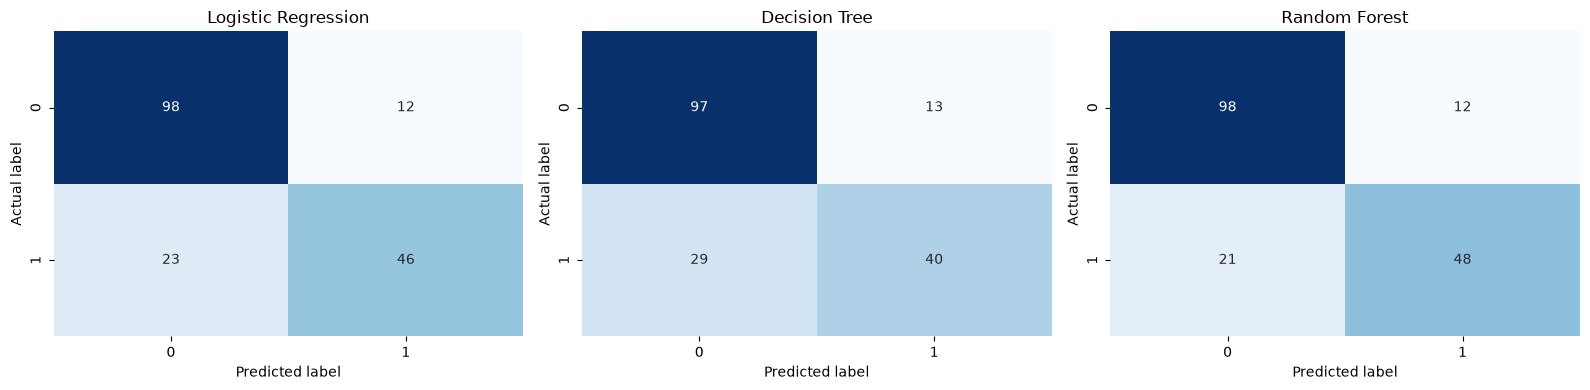

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

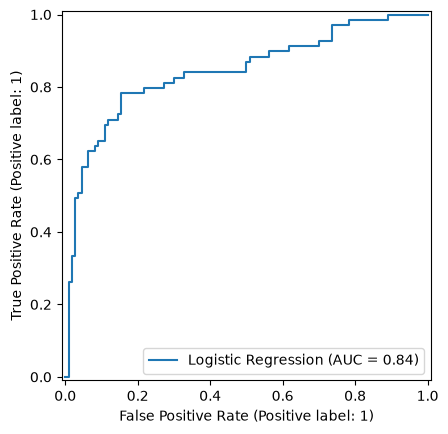

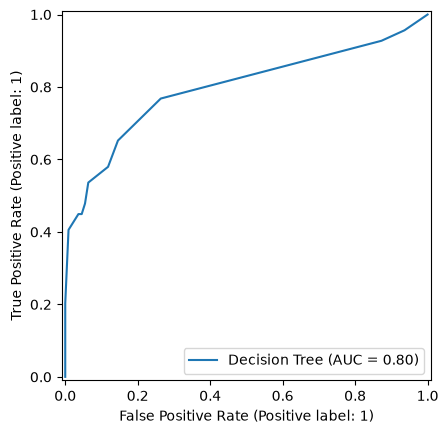

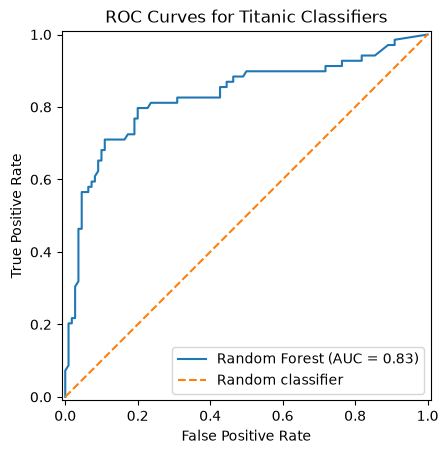

In [17]:
plt.figure(figsize=(8, 6))

for model_name, y_prob in probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("ROC Curves for Titanic Classifiers")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [18]:
for model_name, y_pred in predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Did not survive", "Survived"],
        zero_division=0
    ))

Logistic Regression
                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179

Decision Tree
                 precision    recall  f1-score   support

Did not survive       0.77      0.88      0.82       110
       Survived       0.75      0.58      0.66        69

       accuracy                           0.77       179
      macro avg       0.76      0.73      0.74       179
   weighted avg       0.76      0.77      0.76       179

Random Forest
                 precision    recall  f1-score   support

Did not survive       0.82      0.89      0.86       110
       Survived       0.80      0.70      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      

In [19]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    OUTPUT_DIR / "classification_model_comparison.csv",
    index=False
)

print("Classification comparison saved.")

Classification comparison saved.


In [20]:
from sklearn.tree import plot_tree

In [21]:
decision_tree_pipeline = trained_models["Decision Tree"]

decision_tree_model = decision_tree_pipeline.named_steps["model"]
fitted_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

tree_feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of tree features:", len(tree_feature_names))

Number of tree features: 10


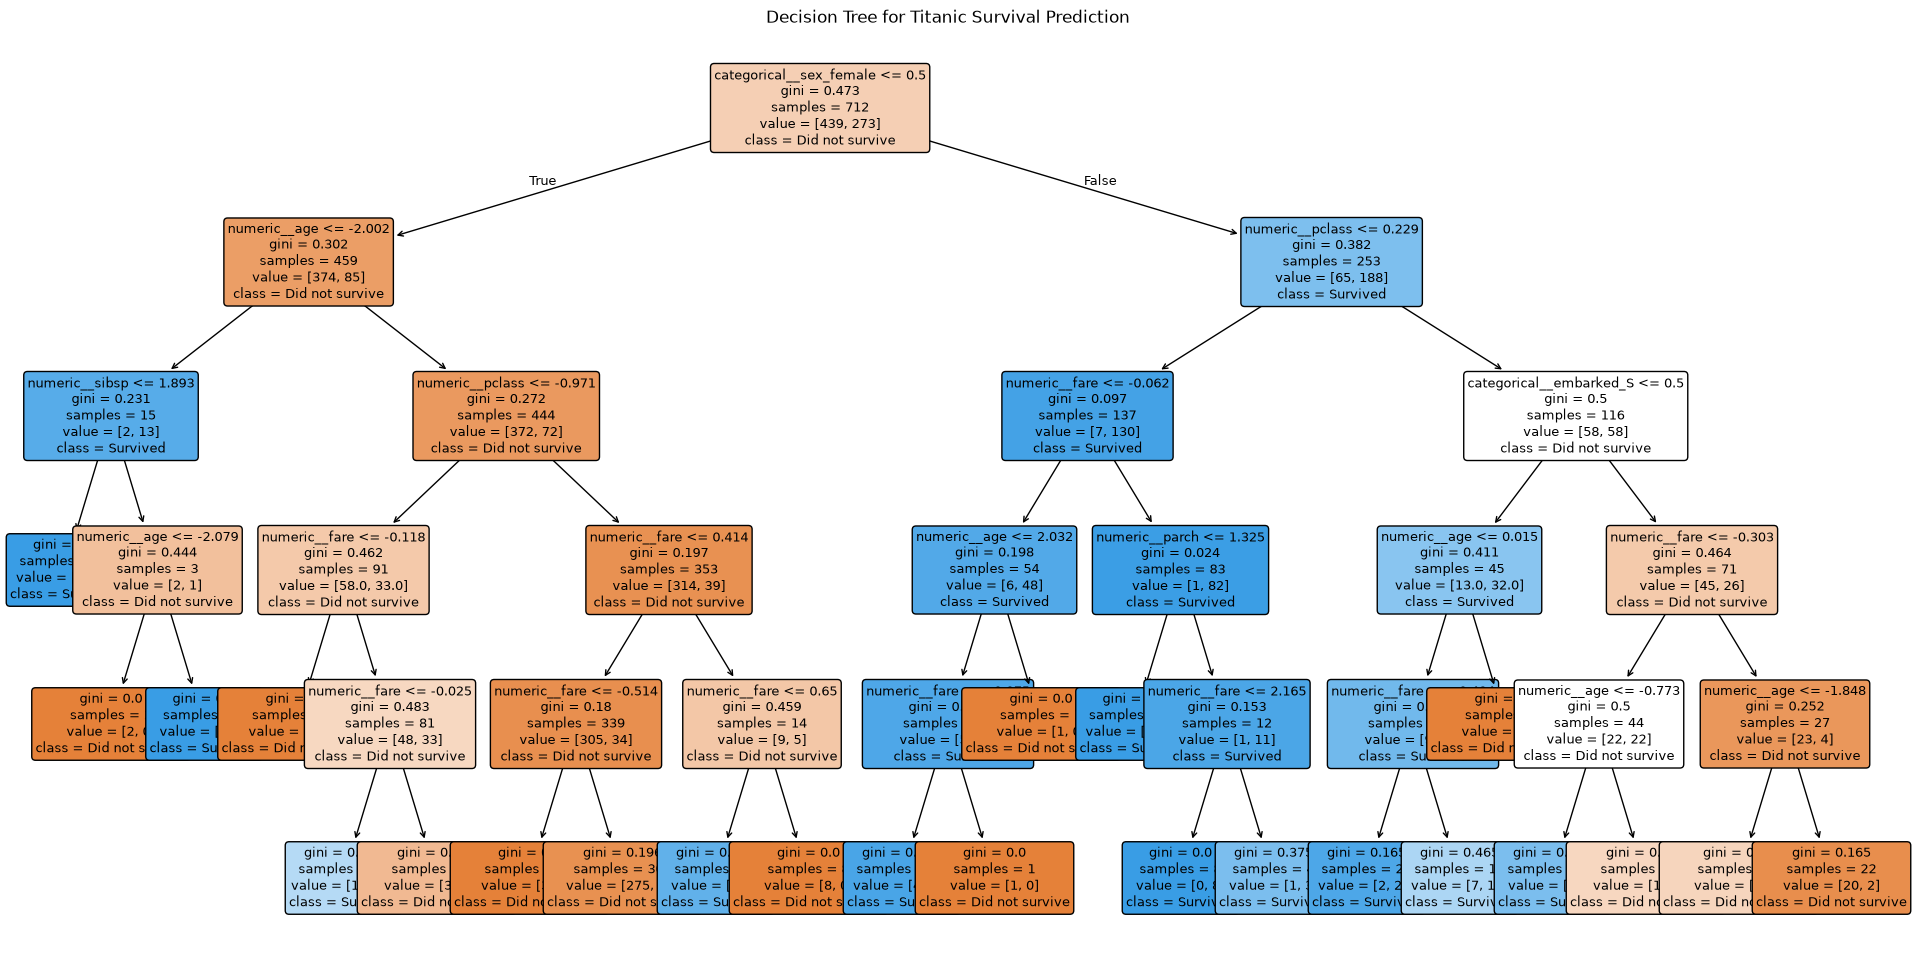

In [22]:
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=tree_feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()

In [23]:
feature_importance_df = pd.DataFrame({
    "Feature": tree_feature_names,
    "Importance": decision_tree_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_df)

,Feature,Importance
5,categorical__sex_female,0.530655
0,numeric__pclass,0.180404
1,numeric__age,0.128719
4,numeric__fare,0.114076
9,categorical__embarked_S,0.034252
2,numeric__sibsp,0.011150
3,numeric__parch,0.000745
6,categorical__sex_male,0.000000
7,categorical__embarked_C,0.000000
8,categorical__embarked_Q,0.000000


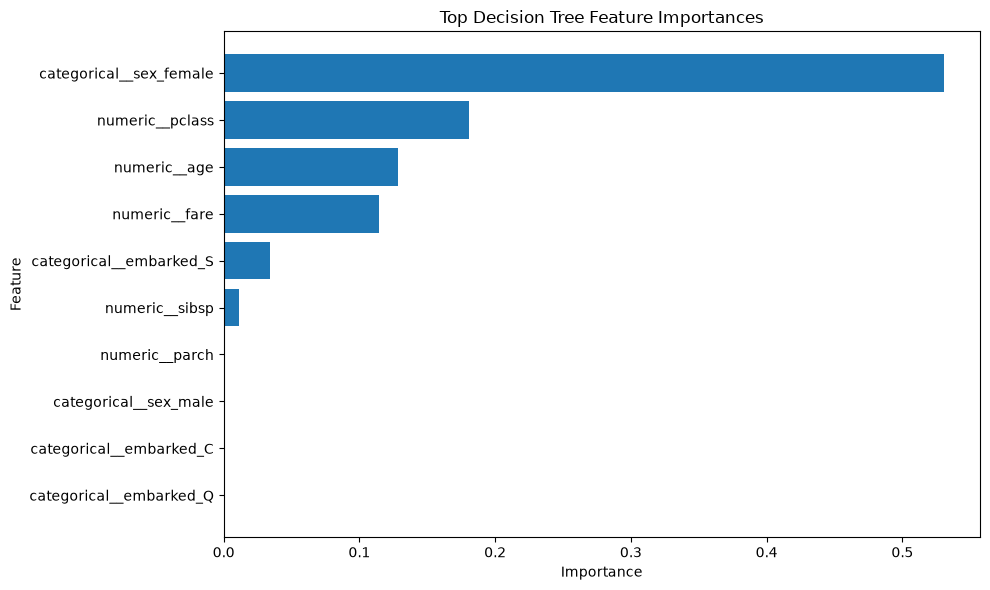

In [24]:
plt.figure(figsize=(10, 6))

top_features = feature_importance_df.head(10)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Decision Tree Interpretation

The Decision Tree achieved an accuracy of [accuracy] and an F1 score of [F1 score] on the test set. The tree visualization shows that [describe the first important split or two]. The most important features were [feature 1], [feature 2], and [feature 3], indicating that these variables contributed most to the model's predictions. Because the tree has a maximum depth of 5, its complexity is limited to reduce the risk of overfitting.

In [25]:
feature_importance_df.to_csv(
    OUTPUT_DIR / "decision_tree_feature_importance.csv",
    index=False
)

print("Decision Tree feature importance saved.")

Decision Tree feature importance saved.


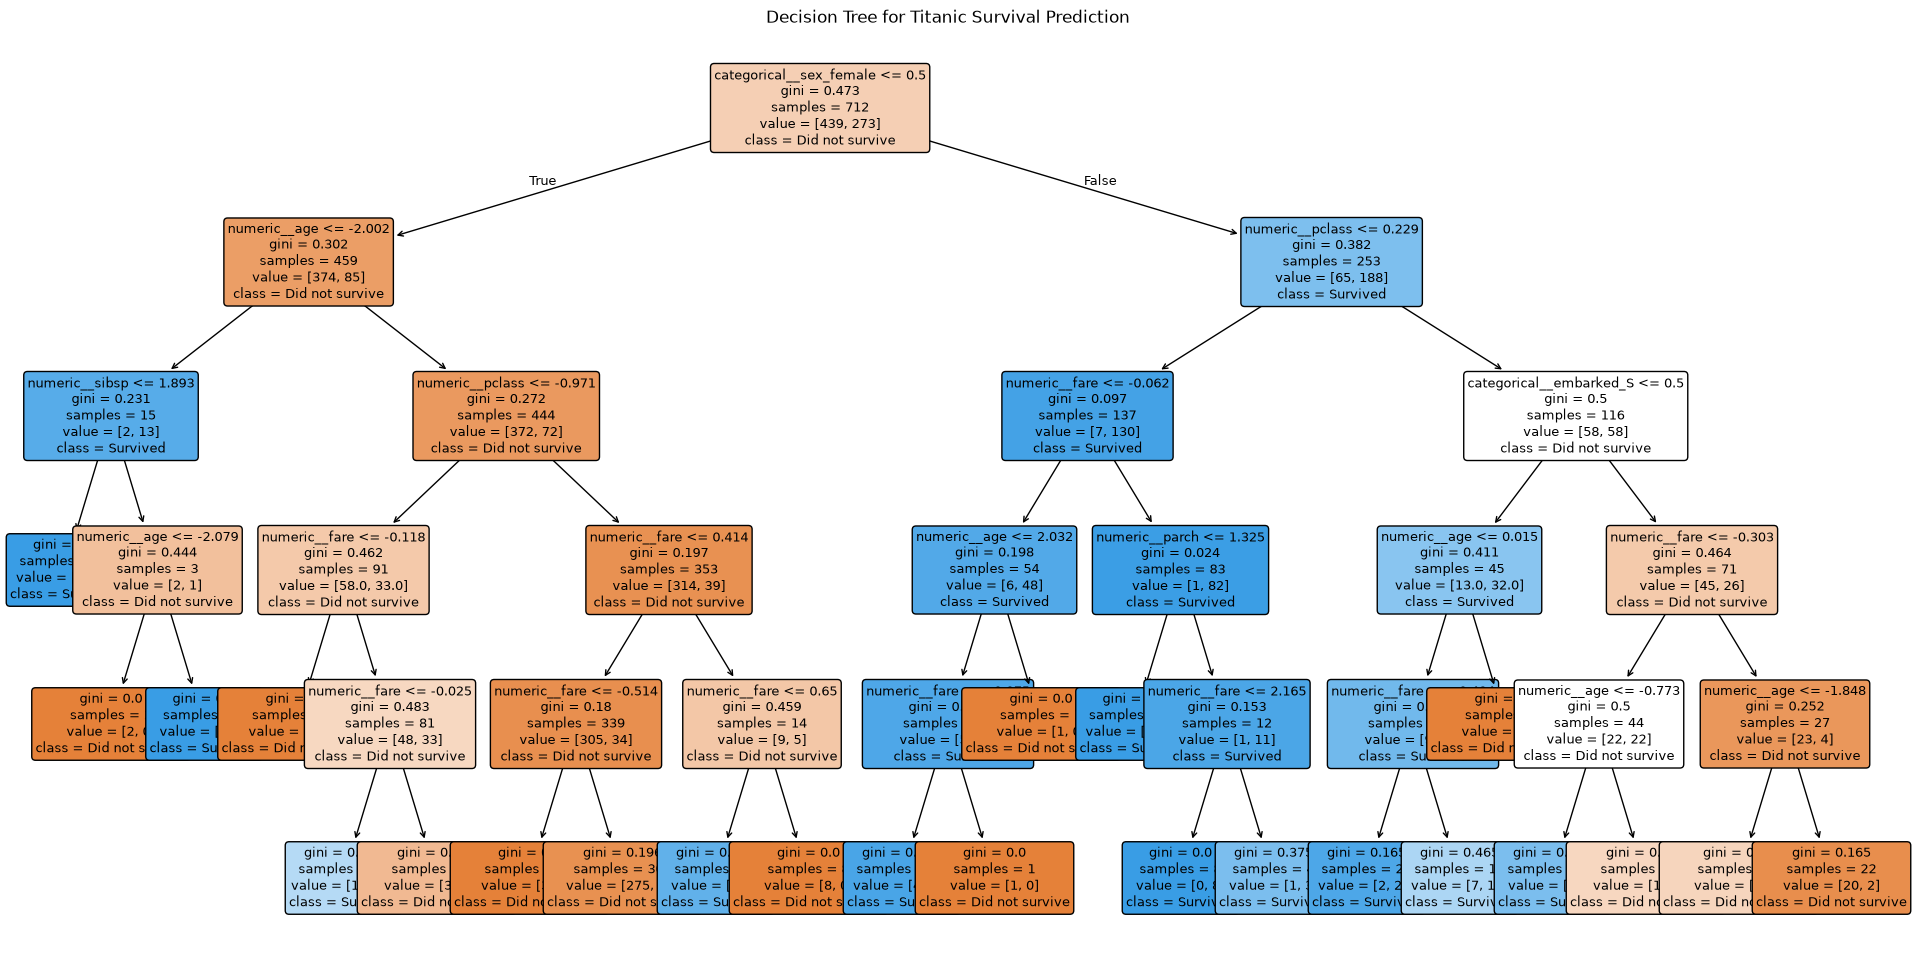

In [26]:
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=tree_feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.savefig(
    OUTPUT_DIR / "decision_tree.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [27]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [28]:
class_balance = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True) * 100
})

display(class_balance.round(2))

,Count,Percentage
survived,,
0,549,61.62
1,342,38.38


### Class Balance

The target variable contains two classes: passengers who did not survive and passengers who survived. The class distribution is not perfectly balanced, so recall, precision, and F1 score are considered alongside accuracy. This is important because accuracy alone may hide poor performance on the smaller class.

In [29]:
imbalance_models = {
    "Baseline Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "Balanced Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SMOTE Random Forest": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ])
}

print("Imbalance models created.")

Imbalance models created.


In [30]:
imbalance_results = []

for model_name, model_pipeline in imbalance_models.items():
    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    imbalance_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

imbalance_results_df = pd.DataFrame(imbalance_results)

display(imbalance_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300
1,Balanced Random Forest,0.8045,0.7500,0.7391,0.7445,0.8227
2,SMOTE Random Forest,0.8101,0.7612,0.7391,0.7500,0.8300


In [31]:
imbalance_results_df.to_csv(
    OUTPUT_DIR / "class_imbalance_comparison.csv",
    index=False
)

print("Class imbalance comparison saved.")

Class imbalance comparison saved.


## Class Imbalance Handling Comparison

The target variable `survived` is imbalanced because the number of passengers who did not survive is greater than the number who survived.

Three approaches were compared:

1. **Baseline:** no explicit imbalance handling.
2. **Class weighting:** `class_weight='balanced'`.
3. **SMOTE:** synthetic minority oversampling applied only to the training data.

The comparison was performed using precision, recall, and F1 score.

SMOTE was applied only to the training portion of the data. This prevents synthetic samples generated from the test set from leaking information into model training.

The results demonstrate that the choice of imbalance strategy affects the precision-recall trade-off. The selected strategy should therefore be based on the metric most relevant to the classification objective rather than accuracy alone.

For this dataset, the comparison should be interpreted together with the F1 score, because F1 balances precision and recall and is more informative than accuracy when the target classes are not perfectly balanced.

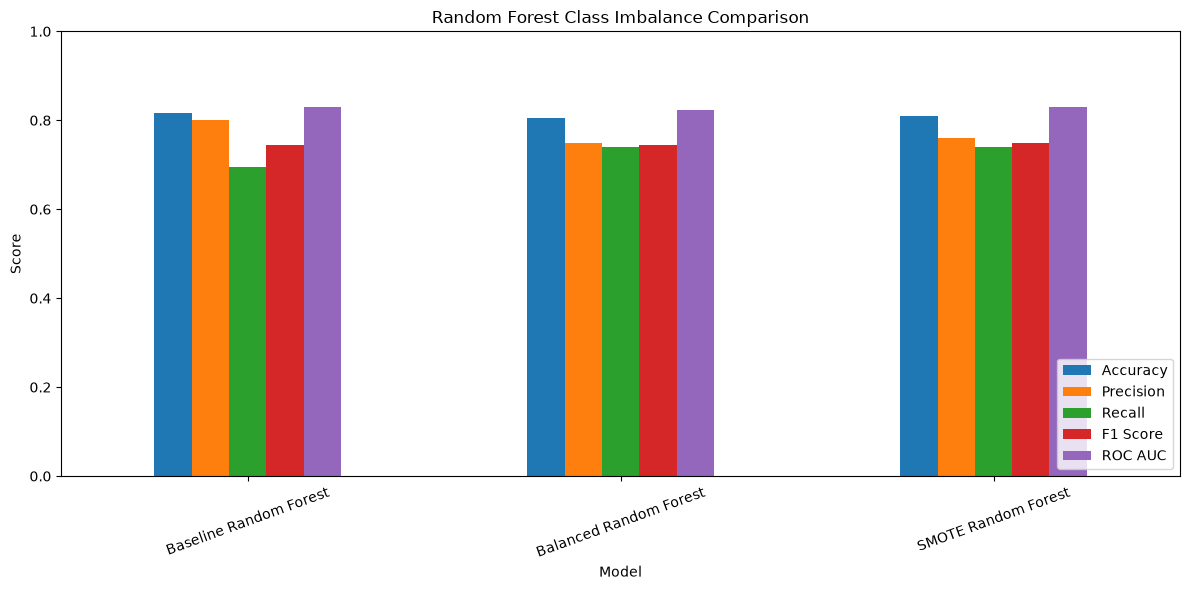

In [32]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

imbalance_results_plot = imbalance_results_df.set_index("Model")[metrics_to_plot]

imbalance_results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Random Forest Class Imbalance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

print("Pipeline imported successfully.")

Pipeline imported successfully.


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor recreated successfully.")

Preprocessor recreated successfully.


In [36]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True,
        bootstrap=True,
        n_jobs=-1
    ))
])

print("Tuning pipeline created.")

Tuning pipeline created.


In [37]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

print("Number of parameter combinations:", 18)

Number of parameter combinations: 18


In [38]:
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split

# Load the saved Titanic dataset
DATA_PATH = Path("titanic.csv")
df = pd.read_csv(DATA_PATH)

# Separate target and features
target = "survived"

X = df.drop(columns=[target])
y = df[target]

# Remove leakage, duplicate, and unnecessary columns
columns_to_drop = [
    "alive",
    "class",
    "who",
    "adult_male",
    "alone",
    "embark_town",
    "deck"
]

X = X.drop(columns=columns_to_drop, errors="ignore")

# Create the same stratified split used earlier
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 7)
X_test: (179, 7)
y_train: (712,)
y_test: (179,)


In [39]:
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Grid search completed.")
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", round(grid_search.best_score_, 4))

Grid search completed.
Best parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Best cross-validation F1 score: 0.7459


In [40]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

In [41]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_predictions = best_rf_pipeline.predict(X_test)
best_rf_probabilities = best_rf_pipeline.predict_proba(X_test)[:, 1]

best_rf_metrics = {
    "Accuracy": accuracy_score(y_test, best_rf_predictions),
    "Precision": precision_score(
        y_test,
        best_rf_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        best_rf_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        best_rf_predictions,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        best_rf_probabilities
    )
}

print("Best Random Forest test metrics:")
for metric, value in best_rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Best Random Forest test metrics:
Accuracy: 0.8156
Precision: 0.8750
Recall: 0.6087
F1 Score: 0.7179
ROC AUC: 0.8431


In [42]:
best_rf_model = best_rf_pipeline.named_steps["model"]

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", round(grid_search.best_score_, 4))
print("OOB score:", round(best_rf_model.oob_score_, 4))

Best parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Best cross-validation F1: 0.7459
OOB score: 0.8272


In [43]:
tuning_results_df = pd.DataFrame(grid_search.cv_results_)

tuning_results_df = tuning_results_df[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(tuning_results_df.head(10))

,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
6,"{'model__max_depth': 5, 'model__max_features':...",0.745929,0.055714,0.795360,1
9,"{'model__max_depth': 5, 'model__max_features':...",0.745929,0.055714,0.795360,1
10,"{'model__max_depth': 5, 'model__max_features':...",0.743587,0.052235,0.796237,3
7,"{'model__max_depth': 5, 'model__max_features':...",0.743587,0.052235,0.796237,3
14,"{'model__max_depth': 10, 'model__max_features'...",0.739185,0.067951,0.939970,5
17,"{'model__max_depth': 10, 'model__max_features'...",0.739185,0.067951,0.939970,5
15,"{'model__max_depth': 10, 'model__max_features'...",0.738832,0.064551,0.938212,7
12,"{'model__max_depth': 10, 'model__max_features'...",0.738832,0.064551,0.938212,7
11,"{'model__max_depth': 5, 'model__max_features':...",0.736620,0.050263,0.798466,9
8,"{'model__max_depth': 5, 'model__max_features':...",0.736620,0.050263,0.798466,9


In [44]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: E:\zepto-ai-ml-capstone\analytics\outputs


In [45]:
tuning_results_df.to_csv(
    OUTPUT_DIR / "random_forest_gridsearch_results.csv",
    index=False
)

best_rf_summary = pd.DataFrame([{
    "Best Parameters": str(grid_search.best_params_),
    "Best CV F1": grid_search.best_score_,
    "Test Accuracy": best_rf_metrics["Accuracy"],
    "Test Precision": best_rf_metrics["Precision"],
    "Test Recall": best_rf_metrics["Recall"],
    "Test F1": best_rf_metrics["F1 Score"],
    "Test ROC AUC": best_rf_metrics["ROC AUC"],
    "OOB Score": best_rf_model.oob_score_
}])

best_rf_summary.to_csv(
    OUTPUT_DIR / "best_random_forest_summary.csv",
    index=False
)

print("Random Forest tuning results saved.")

Random Forest tuning results saved.


## Hyperparameter Tuning — Random Forest

GridSearchCV was used to tune the Random Forest classifier over the required hyperparameters: `n_estimators`, `max_depth`, and `max_features`.

The best hyperparameter combination obtained was:

- **n_estimators:** 100
- **max_depth:** 5
- **max_features:** sqrt

The best cross-validation F1 score was approximately **0.7459**.

The tuned Random Forest was then evaluated on the held-out test set. Its test accuracy was approximately **0.8156**, with a test F1 score of approximately **0.7179** and ROC-AUC of approximately **0.8431**.

The Random Forest was created with `oob_score=True`, producing an out-of-bag score of approximately **0.8272**. The OOB score provides an additional estimate of generalization performance using samples that were not included in the bootstrap sample for individual trees.

Overall, the tuning process identified a relatively shallow Random Forest with 100 trees and `sqrt` feature selection as the best configuration according to the cross-validation objective.

In [46]:
regression_target = "fare"

regression_features = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features].copy()
y_reg = df[regression_target].copy()

print("Regression feature shape:", X_reg.shape)
print("Regression target shape:", y_reg.shape)
print("\nMissing values:")
print(X_reg.isna().sum())
print("\nTarget summary:")
print(y_reg.describe())

Regression feature shape: (891, 7)
Regression target shape: (891,)

Missing values:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
embarked      2
dtype: int64

Target summary:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


In [47]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_reg_train.shape)
print("Regression testing shape:", X_reg_test.shape)

Regression training shape: (712, 7)
Regression testing shape: (179, 7)


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ]
)

print("Regression preprocessor created.")

Regression preprocessor created.


In [49]:
regression_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

print("Regression model trained successfully.")

Regression model trained successfully.


In [50]:
y_reg_pred = regression_pipeline.predict(X_reg_test)

print("First 10 actual fares:")
print(y_reg_test.head(10).to_numpy())

print("\nFirst 10 predicted fares:")
print(y_reg_pred[:10])

First 10 actual fares:
[15.2458 10.5     7.925  33.     11.2417 78.85    7.75   18.      7.75
 26.2833]

First 10 predicted fares:
[38.43446706 29.71114647 -2.87763775 47.72615284 29.87905718 68.84316425
  9.2553379   9.27361252  9.98486511 91.11797661]


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np 

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)

processed_feature_count = len(
    regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - processed_feature_count - 1)
)

regression_metrics = pd.DataFrame([{
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted R2": adjusted_r2
}])

display(regression_metrics.round(4))

,MAE,RMSE,R2,Adjusted R2
0,20.8977,30.5328,0.3975,0.3617


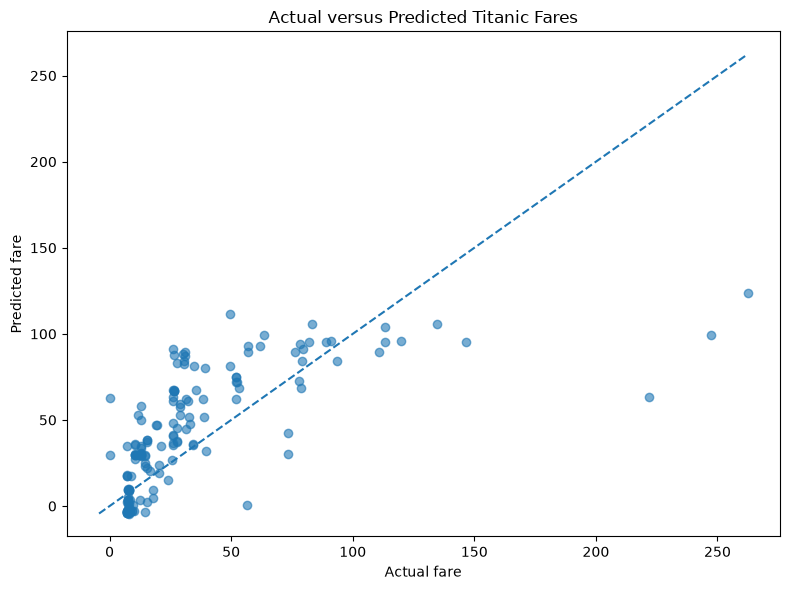

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

plt.scatter(
    y_reg_test,
    y_reg_pred,
    alpha=0.6
)

minimum_value = min(y_reg_test.min(), y_reg_pred.min())
maximum_value = max(y_reg_test.max(), y_reg_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual versus Predicted Titanic Fares")
plt.xlabel("Actual fare")
plt.ylabel("Predicted fare")
plt.tight_layout()
plt.show()

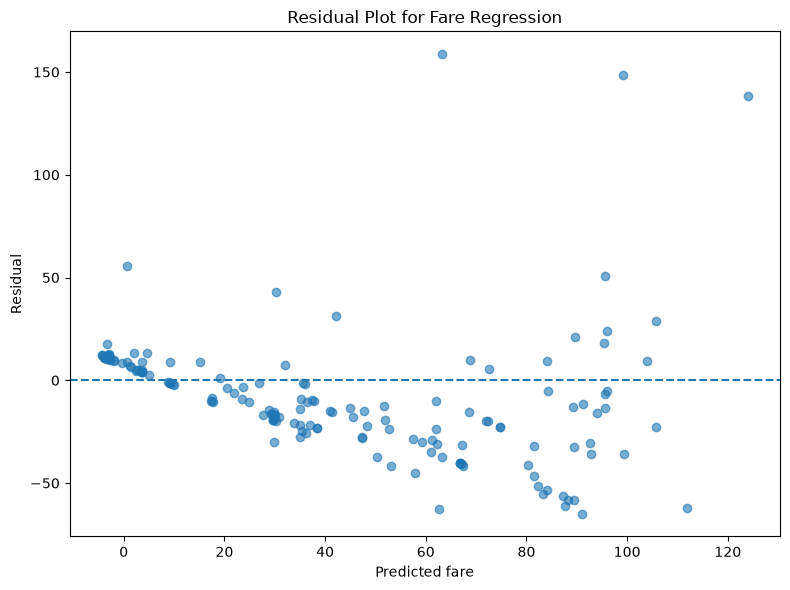

In [53]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot for Fare Regression")
plt.xlabel("Predicted fare")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

### Residual Plot Interpretation

The residual plot shows evidence of heteroscedasticity. The spread of the residuals generally increases as the predicted fare increases, with substantially larger positive and negative residuals at higher predicted fare values. The residuals also show some systematic pattern rather than being completely randomly scattered around zero. Therefore, the linear regression model may violate the constant-variance assumption, which is an important limitation when interpreting the regression results.

## Regression Results — Predicting Fare

A multivariate linear regression model was trained to predict `fare` using the available passenger features.

The model achieved the following results:

- **MAE:** 20.8977
- **RMSE:** 30.5328
- **R²:** 0.3975
- **Adjusted R²:** 0.3617

The MAE indicates that the model's predictions differ from the actual fare by approximately 20.90 fare units on average. The RMSE is higher than the MAE because RMSE gives greater weight to larger prediction errors.

The R² value of approximately 0.3975 indicates that the model explains around 39.75% of the variance in fare. The adjusted R² of approximately 0.3617 is lower because it accounts for the number of predictors included in the model.

Overall, the linear regression provides a useful baseline for predicting fare, but a substantial proportion of the variation in fare remains unexplained by the linear model.

In [54]:
regression_metrics.to_csv(
    OUTPUT_DIR / "fare_regression_metrics.csv",
    index=False
)

print("Regression metrics saved.")

Regression metrics saved.


In [55]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_model_path = MODEL_DIR / "titanic_random_forest_pipeline.joblib"

joblib.dump(
    best_rf_pipeline,
    final_model_path
)

print("Complete model pipeline saved.")
print("Saved to:", final_model_path.resolve())

Complete model pipeline saved.
Saved to: E:\zepto-ai-ml-capstone\analytics\models\titanic_random_forest_pipeline.joblib


In [56]:
loaded_pipeline = joblib.load(final_model_path)

print("Pipeline reloaded successfully.")
print(type(loaded_pipeline))

Pipeline reloaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [57]:
sample_passenger = pd.DataFrame([{
    "pclass": 1,
    "sex": "female",
    "age": 30,
    "sibsp": 0,
    "parch": 0,
    "fare": 80.0,
    "embarked": "C"
}])

sample_prediction = loaded_pipeline.predict(sample_passenger)
sample_probability = loaded_pipeline.predict_proba(sample_passenger)[0, 1]

print("Predicted class:", int(sample_prediction[0]))
print("Probability of survival:", round(sample_probability, 4))

Predicted class: 1
Probability of survival: 0.9844


In [58]:
sample_passengers = pd.DataFrame([
    {
        "pclass": 1,
        "sex": "female",
        "age": 30,
        "sibsp": 0,
        "parch": 0,
        "fare": 80.0,
        "embarked": "C"
    },
    {
        "pclass": 3,
        "sex": "male",
        "age": 25,
        "sibsp": 0,
        "parch": 0,
        "fare": 8.0,
        "embarked": "S"
    },
    {
        "pclass": 2,
        "sex": "female",
        "age": 20,
        "sibsp": 1,
        "parch": 0,
        "fare": 25.0,
        "embarked": "S"
    }
])

sample_predictions = loaded_pipeline.predict(sample_passengers)
sample_probabilities = loaded_pipeline.predict_proba(
    sample_passengers
)[:, 1]

deployment_test_results = sample_passengers.copy()
deployment_test_results["predicted_survival"] = sample_predictions
deployment_test_results["survival_probability"] = sample_probabilities

display(deployment_test_results)

,pclass,sex,age,sibsp,parch,fare,embarked,predicted_survival,survival_probability
0,1,female,30,0,0,80.0,C,1,0.984426
1,3,male,25,0,0,8.0,S,0,0.112345
2,2,female,20,1,0,25.0,S,1,0.819668


In [59]:
deployment_test_results.to_csv(
    OUTPUT_DIR / "deployment_test_predictions.csv",
    index=False
)

print("Deployment test results saved.")

Deployment test results saved.


## Final Classification Model Recommendation

The three classification models were evaluated using accuracy, precision, recall, F1 score, and ROC-AUC.

The Logistic Regression model achieved an accuracy of approximately **0.8045**, an F1 score of approximately **0.7244**, and ROC-AUC of approximately **0.8437**. The Decision Tree achieved an accuracy of approximately **0.7654** and an F1 score of approximately **0.6557**.

The Random Forest achieved an accuracy of approximately **0.8156**, precision of approximately **0.8000**, recall of approximately **0.6957**, and F1 score of approximately **0.7442**.

Based on the combination of these evaluation metrics, **Random Forest provides the strongest overall classification performance among the three tested classifiers**, particularly considering its accuracy and F1 score. The ROC-AUC values should also be considered because they measure the model's ability to distinguish between the two survival classes across classification thresholds.

## Final Model Comparison

The following table provides the final comparison of the three classification models and the separate fare regression model.

Classification models are evaluated using accuracy, precision, recall, F1 score, and ROC-AUC.

The regression model is evaluated separately using MAE, RMSE, R², and Adjusted R². These metrics belong to different modeling tasks and therefore should not be interpreted as being on a common performance scale.

In [60]:
import pandas as pd

# Final classification metrics
final_classification = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8045,
        0.7654,
        0.8156
    ],
    "Precision": [
        0.7931,
        0.7547,
        0.8000
    ],
    "Recall": [
        0.6667,
        0.5797,
        0.6957
    ],
    "F1": [
        0.7244,
        0.6557,
        0.7442
    ],
    "ROC-AUC": [
        0.8437,
        0.7971,
        0.8300
    ]
})

# Regression metrics
regression_result = pd.DataFrame({
    "Model": ["Fare Linear Regression"],
    "MAE": [20.8977],
    "RMSE": [30.5328],
    "R2": [0.3975],
    "Adjusted_R2": [0.3617]
})

# Create final comparison table
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Fare Linear Regression"
    ],
    "Accuracy": [0.8045, 0.7654, 0.8156, None],
    "Precision": [0.7931, 0.7547, 0.8000, None],
    "Recall": [0.6667, 0.5797, 0.6957, None],
    "F1": [0.7244, 0.6557, 0.7442, None],
    "ROC-AUC": [0.8437, 0.7971, 0.8300, None],
    "MAE": [None, None, None, 20.8977],
    "RMSE": [None, None, None, 30.5328],
    "R2": [None, None, None, 0.3975],
    "Adjusted_R2": [None, None, None, 0.3617]
})

print("FINAL MODEL COMPARISON")
display(final_comparison)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MAE,RMSE,R2,Adjusted_R2
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437,NaN,NaN,NaN,NaN
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971,NaN,NaN,NaN,NaN
2,Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300,NaN,NaN,NaN,NaN
3,Fare Linear Regression,NaN,NaN,NaN,NaN,NaN,20.8977,30.5328,0.3975,0.3617


### Comparison Interpretation

The classification results show that the three models have different precision-recall trade-offs. Random Forest achieves the highest accuracy and F1 score among the three classifiers, while Logistic Regression achieves the highest ROC-AUC in the reported results.

For the regression task, the fare prediction model achieves an R² of approximately 0.3975 and an adjusted R² of approximately 0.3617, indicating that the linear model explains a moderate portion of the variation in fare.

The classification and regression results are reported as separate metric groups because they measure different predictive tasks and are therefore not directly comparable.